1. Importar librerías

In [1]:
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/DAIC-WOZ"

Mounted at /content/drive


2. Leer la transcripción de un participante

In [2]:
transcripts = sorted([
    f for f in os.listdir(BASE)
    if f.endswith("_TRANSCRIPT.csv") and not f.startswith("._")
])

print("Número de transcripciones:", len(transcripts))
print(transcripts[:10])

Número de transcripciones: 189
['300_TRANSCRIPT.csv', '301_TRANSCRIPT.csv', '302_TRANSCRIPT.csv', '303_TRANSCRIPT.csv', '304_TRANSCRIPT.csv', '305_TRANSCRIPT.csv', '306_TRANSCRIPT.csv', '307_TRANSCRIPT.csv', '308_TRANSCRIPT.csv', '309_TRANSCRIPT.csv']


3. Abrir una transcripcion

In [3]:
archivo = os.path.join(BASE, transcripts[0])

df = pd.read_csv(archivo)

df.head()

,start_time\tstop_time\tspeaker\tvalue
0,36.588\t39.668\tEllie\thi i'm ellie thanks for...
1,39.888\t43.378\tEllie\ti was created to talk t...
2,43.728\t48.498\tEllie\tthink of me as a friend...
3,49.188\t52.388\tEllie\ti'm here to learn about...
4,52.658\t58.958\tEllie\ti'll ask a few question...


4. Carga y visualización de un archivo TRANSCRIPT.csv

In [4]:
archivo = os.path.join(BASE, transcripts[0])

df = pd.read_csv(archivo, sep="\t")

df.head()

,start_time,stop_time,speaker,value
0,36.588,39.668,Ellie,hi i'm ellie thanks for coming in today
1,39.888,43.378,Ellie,i was created to talk to people in a safe and ...
2,43.728,48.498,Ellie,think of me as a friend i don't judge i can't ...
3,49.188,52.388,Ellie,i'm here to learn about people and would love ...
4,52.658,58.958,Ellie,i'll ask a few questions to get us started and...


5. Análisis de la estructura del DataFrame

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   start_time  174 non-null    float64
 1   stop_time   174 non-null    float64
 2   speaker     174 non-null    object 
 3   value       174 non-null    object 
dtypes: float64(2), object(2)
memory usage: 5.6+ KB


6. Filtrado de las intervenciones del participante

In [6]:
# Conservar únicamente las intervenciones del participante
participant_df = df[df["speaker"] == "Participant"].copy()

# Mostrar las primeras filas
participant_df.head()

,start_time,stop_time,speaker,value
6,62.328,63.178,Participant,good
9,68.978,70.288,Participant,atlanta georgia
12,75.028,78.128,Participant,um my parents are from here um
14,83.808,84.588,Participant,i love it
16,88.458,89.968,Participant,i like the weather


7. Verificación del filtrado del participante

In [7]:
print("Número total de intervenciones:", len(df))
print("Intervenciones del participante:", len(participant_df))

print("\nParticipantes encontrados:")
print(participant_df["speaker"].unique())

Número total de intervenciones: 174
Intervenciones del participante: 87

Participantes encontrados:
['Participant']


8. Limpieza y preprocesamiento del texto

In [8]:
# Unir todas las intervenciones del participante
texto = " ".join(participant_df["value"].astype(str))

print(texto[:1000])

good atlanta georgia um my parents are from here um i love it i like the weather i like the opportunities um yes um it took a minute somewhat easy congestion that's it um i took up business and administration uh yeah i am here and there i'm on a break right now but i plan on going back in the uh next semester uh probably to open up my own business no um no specific reason i just don't travel a lot i'm pretty local once a year can you be a little bit more specific no answer i like reading books i enjoy i enjoy cooking um exercising is great i'm i'm i'm pretty good at it um yeah um probably about two weeks ago uh frustrated um i don't like bias um i don't like um when someone says they're gonna do something and they don't uh somewhat friendship i like to play sports i enjoy uh going out with friends and family playing games grandparents parents um yeah i mean they've always given me great advice they've always kept it real real close i would say going to college right after high school w

9. Estadísticas básicas del texto

In [9]:
print("Número de caracteres:", len(texto))
print("Número de palabras:", len(texto.split()))

Número de caracteres: 1757
Número de palabras: 352


10. Limpieza básica del texto

In [10]:
import re

texto_limpio = texto.lower()

texto_limpio = re.sub(r'\s+', ' ', texto_limpio)

texto_limpio = texto_limpio.strip()

print(texto_limpio[:1000])

good atlanta georgia um my parents are from here um i love it i like the weather i like the opportunities um yes um it took a minute somewhat easy congestion that's it um i took up business and administration uh yeah i am here and there i'm on a break right now but i plan on going back in the uh next semester uh probably to open up my own business no um no specific reason i just don't travel a lot i'm pretty local once a year can you be a little bit more specific no answer i like reading books i enjoy i enjoy cooking um exercising is great i'm i'm i'm pretty good at it um yeah um probably about two weeks ago uh frustrated um i don't like bias um i don't like um when someone says they're gonna do something and they don't uh somewhat friendship i like to play sports i enjoy uh going out with friends and family playing games grandparents parents um yeah i mean they've always given me great advice they've always kept it real real close i would say going to college right after high school w

11. Instalación de la biblioteca Transformers

In [11]:
!pip -q install transformers torch sentencepiece

12. Carga del tokenizador y modelo bert-base-uncased

In [12]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


13. Tokenización del texto con BERT

In [13]:
# Tokenizar el texto del participante
inputs = tokenizer(
    texto_limpio,
    return_tensors="pt",
    truncation=True,
    padding="max_length",
    max_length=512
)

inputs

{'input_ids': tensor([[  101,  2204,  5865,  4108,  8529,  2026,  3008,  2024,  2013,  2182,
          8529,  1045,  2293,  2009,  1045,  2066,  1996,  4633,  1045,  2066,
          1996,  6695,  8529,  2748,  8529,  2009,  2165,  1037,  3371,  5399,
          3733, 20176,  2008,  1005,  1055,  2009,  8529,  1045,  2165,  2039,
          2449,  1998,  3447,  7910,  3398,  1045,  2572,  2182,  1998,  2045,
          1045,  1005,  1049,  2006,  1037,  3338,  2157,  2085,  2021,  1045,
          2933,  2006,  2183,  2067,  1999,  1996,  7910,  2279, 13609,  7910,
          2763,  2000,  2330,  2039,  2026,  2219,  2449,  2053,  8529,  2053,
          3563,  3114,  1045,  2074,  2123,  1005,  1056,  3604,  1037,  2843,
          1045,  1005,  1049,  3492,  2334,  2320,  1037,  2095,  2064,  2017,
          2022,  1037,  2210,  2978,  2062,  3563,  2053,  3437,  1045,  2066,
          3752,  2808,  1045,  5959,  1045,  5959,  8434,  8529, 28428,  2003,
          2307,  1045,  1005,  1049,  

14. Generación de embeddings contextuales

In [14]:
import torch

with torch.no_grad():
    outputs = model(**inputs)

15. Obtención del embedding de la entrevista

In [15]:
embeddings = outputs.last_hidden_state

print(embeddings.shape)

torch.Size([1, 512, 768])


16. Extracción del vector representativo de la entrevista

In [16]:
embedding_documento = embeddings[:, 0, :]

print(embedding_documento.shape)

torch.Size([1, 768])


17. Conversión del embedding a NumPy

In [17]:
embedding_documento = embedding_documento.squeeze().numpy()

print(type(embedding_documento))
print(embedding_documento.shape)

<class 'numpy.ndarray'>
(768,)


18. Generación de embeddings para todas las entrevistas

In [18]:
import os
import pandas as pd
import torch

# Lista para almacenar los embeddings
embeddings_lista = []

# Lista para almacenar la longitud de cada transcript
tokens_info = []

for archivo in transcripts:

    try:

        # ID del participante
        participante = archivo.split("_")[0]

        # Leer transcript
        ruta = os.path.join(BASE, archivo)
        df = pd.read_csv(ruta, sep="\t")

        # Conservar únicamente las intervenciones del participante
        participant_df = df[df["speaker"] == "Participant"]

        # Unir todas las intervenciones
        texto = " ".join(
            participant_df["value"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        texto = texto.lower().strip()

        # ==========================================
        # Conteo de tokens ANTES del truncamiento
        # ==========================================

        num_tokens = len(tokenizer.tokenize(texto))

        tokens_info.append({
            "Participant_ID": participante,
            "Num_Tokens": num_tokens
        })

        # ==========================================
        # Tokenización para BERT
        # ==========================================

        inputs = tokenizer(
            texto,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=512
        )

        # Embedding contextual
        with torch.no_grad():
            outputs = model(**inputs)

        embedding = outputs.last_hidden_state[:, 0, :]

        embedding = embedding.squeeze().numpy()

        fila = {
            "Participant_ID": participante
        }

        for i, valor in enumerate(embedding):
            fila[f"emb_{i+1}"] = valor

        embeddings_lista.append(fila)

    except Exception as e:
        print(f"Error en {archivo}: {e}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1743 > 512). Running this sequence through the model will result in indexing errors


19. Análisis del límite de 512 tokens

In [19]:
# ============================================
# Análisis del límite de 512 tokens de BERT
# ============================================

tokens_df = pd.DataFrame(tokens_info)

print(tokens_df.head())

print("\nNúmero de participantes:", len(tokens_df))

print("Máximo número de tokens:",
      tokens_df["Num_Tokens"].max())

print("Promedio de tokens:",
      round(tokens_df["Num_Tokens"].mean(), 2))

superan = (tokens_df["Num_Tokens"] > 512).sum()

print("\nParticipantes con más de 512 tokens:", superan)

print(
    "Porcentaje:",
    round(100 * superan / len(tokens_df), 2),
    "%"
)

  Participant_ID  Num_Tokens
0            300         394
1            301        1743
2            302         685
3            303        2224
4            304        1153

Número de participantes: 189
Máximo número de tokens: 5332
Promedio de tokens: 1703.45

Participantes con más de 512 tokens: 185
Porcentaje: 97.88 %


20. Distribución de los tokens

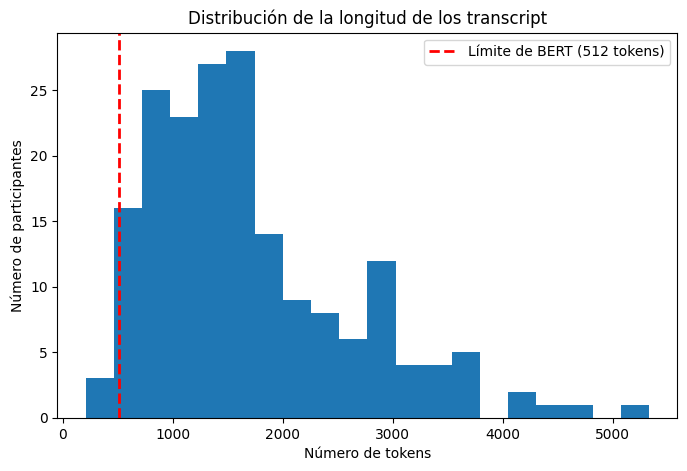

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(tokens_df["Num_Tokens"], bins=20)

plt.axvline(
    512,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Límite de BERT (512 tokens)"
)

plt.xlabel("Número de tokens")

plt.ylabel("Número de participantes")

plt.title("Distribución de la longitud de los transcript")

plt.legend()

plt.show()

21. Construcción del DataFrame de embeddings

In [21]:
embeddings_df = pd.DataFrame(embeddings_lista)

print(embeddings_df.shape)

embeddings_df.head()

(189, 769)


,Participant_ID,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,emb_768
0,300,-0.112955,-0.061918,0.222395,0.048890,-0.252634,-0.555971,0.448568,0.418681,0.263050,...,0.358922,-0.769546,-0.189620,-0.117711,0.454043,0.593515,-0.515235,-0.298067,0.434498,-0.159319
1,301,0.121853,0.215928,0.443456,-0.043890,-0.531167,-0.161103,0.398759,0.763766,-0.263526,...,0.053358,-1.017370,-0.268402,-0.238128,0.308190,0.548508,-0.352331,-0.358936,0.046518,0.029245
2,302,-0.170798,-0.025300,0.516748,-0.038272,-0.321412,-0.386232,0.391583,0.772732,-0.119591,...,0.028563,-0.831491,-0.261475,-0.281166,0.387638,0.506170,-0.212112,-0.102939,0.502793,-0.343355
3,303,-0.102620,0.263089,0.237846,0.204002,-0.170751,-0.105257,0.155405,0.874446,-0.230149,...,-0.142430,-0.955053,-0.093463,-0.298892,0.362784,0.523140,-0.216216,-0.460964,-0.135334,-0.252775
4,304,0.031289,-0.076062,0.399899,0.101374,-0.302885,0.020719,0.390248,0.673135,-0.016671,...,0.038919,-0.711380,-0.115885,0.019373,0.149931,0.414613,-0.346800,-0.336720,0.274709,-0.392734


22. Guardar los embeddings generados

In [22]:
ruta_salida = os.path.join(BASE, "Embeddings_BERT.csv")

embeddings_df.to_csv(ruta_salida, index=False)

print("Archivo guardado en:")
print(ruta_salida)

Archivo guardado en:
/content/drive/MyDrive/DAIC-WOZ/Embeddings_BERT.csv


23. Carga de los archivos con las etiquetas de depresión de entrenamiento y prueba

In [26]:
# Conjunto de entrenamiento (Development)
dev_df = pd.read_csv(
    os.path.join(BASE, "dev_split_Depression_AVEC2017.csv")
)

# Conjunto de prueba (Test)
test_df = pd.read_csv(
    os.path.join(BASE, "full_test_split.csv")
)

# Homologar nombres del conjunto de prueba
test_df = test_df.rename(
    columns={
        "PHQ_Binary": "PHQ8_Binary",
        "PHQ_Score": "PHQ8_Score"
    }
)

# Conservar únicamente las columnas utilizadas en ambos conjuntos
dev_df = dev_df[
    [
        "Participant_ID",
        "PHQ8_Binary",
        "PHQ8_Score"
    ]
]

test_df = test_df[
    [
        "Participant_ID",
        "PHQ8_Binary",
        "PHQ8_Score"
    ]
]

print("Entrenamiento:", dev_df.shape)
print("Prueba:", test_df.shape)

Entrenamiento: (35, 3)
Prueba: (47, 3)


24. Reconstrucción de los conjuntos de datos

In [29]:
# ============================================
# Reconstrucción de los conjuntos de datos
# ============================================

# Homologar el tipo de dato del identificador
embeddings_df["Participant_ID"] = embeddings_df["Participant_ID"].astype(int)
dev_df["Participant_ID"] = dev_df["Participant_ID"].astype(int)
test_df["Participant_ID"] = test_df["Participant_ID"].astype(int)

# Construcción del conjunto de entrenamiento
texto_train = embeddings_df.merge(
    dev_df,
    on="Participant_ID",
    how="inner"
)

# Construcción del conjunto de prueba
texto_test = embeddings_df.merge(
    test_df,
    on="Participant_ID",
    how="inner"
)

print("Train:", texto_train.shape)
print("Test :", texto_test.shape)

Train: (35, 771)
Test : (47, 771)


25. Preparación de los datos

In [30]:
from sklearn.preprocessing import StandardScaler

# Variables predictoras
X_train = texto_train.drop(
    columns=[
        "Participant_ID",
        "PHQ8_Binary",
        "PHQ8_Score"
    ]
)

X_test = texto_test.drop(
    columns=[
        "Participant_ID",
        "PHQ8_Binary",
        "PHQ8_Score"
    ]
)

# Variable objetivo
y_train = texto_train["PHQ8_Binary"]
y_test = texto_test["PHQ8_Binary"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Escalamiento
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train: (35, 768)
X_test : (47, 768)


26. Entrenamiento del clasificador

In [31]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo.fit(X_train, y_train)

print("Entrenamiento finalizado correctamente.")

Entrenamiento finalizado correctamente.


27. Evaluación

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predicciones
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("AUC ROC  :", round(auc,4))

print("\nMatriz de Confusión")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación")
print(classification_report(y_test, y_pred))

Accuracy : 0.6383
Precision: 0.3636
Recall   : 0.2857
F1 Score : 0.32
AUC ROC  : 0.5996

Matriz de Confusión
[[26  7]
 [10  4]]

Reporte de Clasificación
              precision    recall  f1-score   support

           0       0.72      0.79      0.75        33
           1       0.36      0.29      0.32        14

    accuracy                           0.64        47
   macro avg       0.54      0.54      0.54        47
weighted avg       0.62      0.64      0.62        47



28. Resumen de las métricas

In [33]:
# ============================================
# Celda 28. Resumen de resultados
# ============================================

import pandas as pd

resultados = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "AUC-ROC"
    ],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

resultados

,Métrica,Valor
0,Accuracy,0.638298
1,Precision,0.363636
2,Recall,0.285714
3,F1-Score,0.320000
4,AUC-ROC,0.599567


29. Matriz de confusión

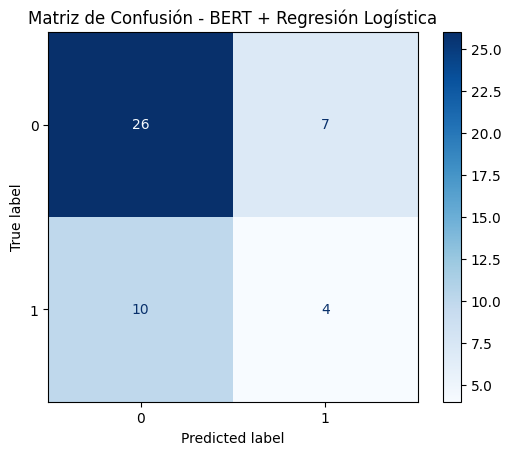

In [34]:
# ============================================
# Celda 29. Matriz de confusión
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Matriz de Confusión - BERT + Regresión Logística")
plt.show()

30. Curva ROC

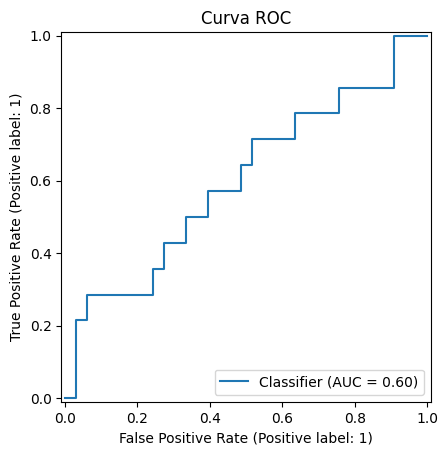

In [35]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Curva ROC")
plt.show()

31. Comparación de resultados

In [36]:
comparacion = pd.DataFrame({
    "Modelo": ["Texto (BERT + Logistic Regression)"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1],
    "AUC-ROC": [auc]
})

comparacion

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Texto (BERT + Logistic Regression),0.638298,0.363636,0.285714,0.32,0.599567


32. Activar las salidas ocultas de BERT

In [37]:
from transformers import BertTokenizer, BertModel

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

model = BertModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True
)

model.eval()

print("Modelo cargado correctamente.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado correctamente.


33. Generación de embeddings utilizando Mean Pooling

In [38]:
# ============================================
# 33. Generación de embeddings con Mean Pooling
# ============================================

import os
import pandas as pd
import torch

embeddings_mean = []

for archivo in transcripts:

    try:

        participante = archivo.split("_")[0]

        ruta = os.path.join(BASE, archivo)

        df = pd.read_csv(ruta, sep="\t")

        participant_df = df[df["speaker"] == "Participant"]

        texto = " ".join(
            participant_df["value"]
            .fillna("")
            .astype(str)
            .tolist()
        )

        texto = texto.lower().strip()

        inputs = tokenizer(
            texto,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=512
        )

        with torch.no_grad():

            outputs = model(**inputs)

        # ========================================
        # Mean Pooling
        # ========================================

        embedding = outputs.last_hidden_state.mean(dim=1)

        embedding = embedding.squeeze().numpy()

        fila = {
            "Participant_ID": int(participante)
        }

        for i, valor in enumerate(embedding):

            fila[f"emb_{i+1}"] = valor

        embeddings_mean.append(fila)

    except Exception as e:

        print(f"Error en {archivo}: {e}")

print("Embeddings generados:", len(embeddings_mean))

Embeddings generados: 189


34. Construcción del DataFrame de Mean Pooling

In [39]:
# ============================================
# 34. DataFrame de Mean Pooling
# ============================================

embeddings_mean_df = pd.DataFrame(embeddings_mean)

print("Dimensiones:", embeddings_mean_df.shape)

embeddings_mean_df.head()

Dimensiones: (189, 769)


,Participant_ID,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,emb_768
0,300,0.144788,-0.019870,0.430707,-0.022452,0.103504,-0.160537,-0.022517,0.572074,0.034602,...,-0.082472,-0.304190,0.093779,-0.095303,0.010158,-0.314174,-0.236098,-0.042204,-0.058674,0.010551
1,301,0.194614,0.053655,0.364101,-0.015164,0.046588,-0.209192,0.096614,0.638380,0.043026,...,-0.151189,-0.260692,0.151375,-0.108128,-0.085025,-0.041038,-0.084612,-0.169042,-0.078903,0.139439
2,302,0.041461,-0.040609,0.296698,-0.058696,0.172372,-0.168958,-0.047283,0.669629,-0.069803,...,-0.162272,-0.285114,0.089535,-0.099655,-0.029451,-0.222900,-0.148177,-0.046588,-0.027374,0.084799
3,303,0.033516,0.035616,0.344269,-0.072222,0.261552,-0.181094,0.164686,0.657522,-0.020883,...,-0.219762,-0.329728,0.133839,-0.086140,-0.112366,0.000562,-0.098617,-0.143383,-0.053916,-0.061605
4,304,-0.051860,0.008852,0.294591,-0.035483,0.167419,-0.030138,0.087264,0.582690,0.028006,...,-0.159520,-0.367384,0.104274,-0.148119,-0.121531,-0.139681,-0.095507,-0.133078,0.013326,0.045164


35. Construcción de Train y Test

In [40]:
# ============================================
# 35. Construcción de Train y Test
# ============================================

texto_train_mean = embeddings_mean_df.merge(
    dev_df,
    on="Participant_ID",
    how="inner"
)

texto_test_mean = embeddings_mean_df.merge(
    test_df,
    on="Participant_ID",
    how="inner"
)

print("Train:", texto_train_mean.shape)
print("Test :", texto_test_mean.shape)

Train: (35, 771)
Test : (47, 771)


36. Preparación de los datos

In [41]:
# ============================================
# 36. Preparación de los datos
# ============================================

from sklearn.preprocessing import StandardScaler

X_train_mean = texto_train_mean.drop(
    columns=[
        "Participant_ID",
        "PHQ8_Binary",
        "PHQ8_Score"
    ]
)

X_test_mean = texto_test_mean.drop(
    columns=[
        "Participant_ID",
        "PHQ8_Binary",
        "PHQ8_Score"
    ]
)

y_train_mean = texto_train_mean["PHQ8_Binary"]

y_test_mean = texto_test_mean["PHQ8_Binary"]

print("X_train:", X_train_mean.shape)
print("X_test :", X_test_mean.shape)

scaler_mean = StandardScaler()

X_train_mean = scaler_mean.fit_transform(X_train_mean)

X_test_mean = scaler_mean.transform(X_test_mean)

X_train: (35, 768)
X_test : (47, 768)


37. Entrenamiento

In [42]:
# ============================================
# 37. Entrenamiento
# ============================================

from sklearn.linear_model import LogisticRegression

modelo_mean = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo_mean.fit(
    X_train_mean,
    y_train_mean
)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


38. Evaluación del modelo Mean Pooling

In [43]:
# ============================================
# 38. Evaluación del modelo Mean Pooling
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predicciones
y_pred_mean = modelo_mean.predict(X_test_mean)
y_prob_mean = modelo_mean.predict_proba(X_test_mean)[:, 1]

# Métricas
accuracy_mean = accuracy_score(y_test_mean, y_pred_mean)
precision_mean = precision_score(y_test_mean, y_pred_mean)
recall_mean = recall_score(y_test_mean, y_pred_mean)
f1_mean = f1_score(y_test_mean, y_pred_mean)
auc_mean = roc_auc_score(y_test_mean, y_prob_mean)

print("Accuracy :", round(accuracy_mean,4))
print("Precision:", round(precision_mean,4))
print("Recall   :", round(recall_mean,4))
print("F1 Score :", round(f1_mean,4))
print("AUC ROC  :", round(auc_mean,4))

print("\nMatriz de Confusión")
print(confusion_matrix(y_test_mean, y_pred_mean))

print("\nReporte de Clasificación")
print(classification_report(y_test_mean, y_pred_mean))

Accuracy : 0.617
Precision: 0.3333
Recall   : 0.2857
F1 Score : 0.3077
AUC ROC  : 0.6255

Matriz de Confusión
[[25  8]
 [10  4]]

Reporte de Clasificación
              precision    recall  f1-score   support

           0       0.71      0.76      0.74        33
           1       0.33      0.29      0.31        14

    accuracy                           0.62        47
   macro avg       0.52      0.52      0.52        47
weighted avg       0.60      0.62      0.61        47



39. Matriz de confusión

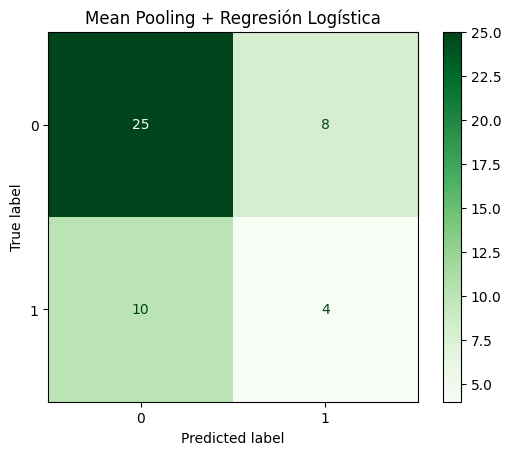

In [44]:
# ============================================
# 39. Matriz de confusión
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_mean,
    y_pred_mean,
    cmap="Greens"
)

plt.title("Mean Pooling + Regresión Logística")

plt.show()

40. Curva ROC

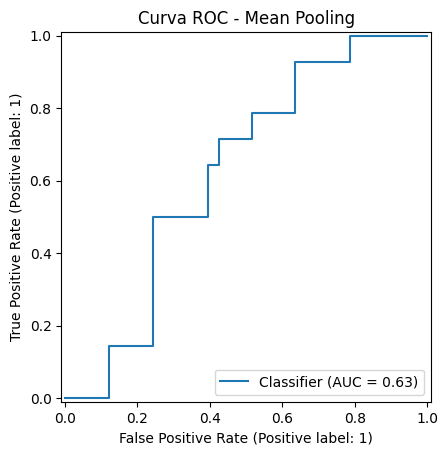

In [45]:
# ============================================
# 40. Curva ROC
# ============================================

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test_mean,
    y_prob_mean
)

plt.title("Curva ROC - Mean Pooling")

plt.show()

41. Comparación CLS vs Mean Pooling

In [46]:
# ============================================
# 41. Comparación de estrategias
# ============================================

comparacion_embeddings = pd.DataFrame({

    "Representación": [
        "CLS",
        "Mean Pooling"
    ],

    "Accuracy": [
        accuracy,
        accuracy_mean
    ],

    "Precision": [
        precision,
        precision_mean
    ],

    "Recall": [
        recall,
        recall_mean
    ],

    "F1-Score": [
        f1,
        f1_mean
    ],

    "AUC-ROC": [
        auc,
        auc_mean
    ]

})

comparacion_embeddings

,Representación,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,CLS,0.638298,0.363636,0.285714,0.320000,0.599567
1,Mean Pooling,0.617021,0.333333,0.285714,0.307692,0.625541


Celda Markdown 1
Análisis del límite de 512 tokens

# Análisis del límite de 512 tokens

El modelo **BERT Base** admite un máximo de **512 tokens** por entrada. Por esta razón, antes de generar los embeddings se analizó la longitud de cada transcript con el fin de identificar cuántas entrevistas superaban dicho límite.

Los resultados muestran que una proporción importante de los transcript contiene más de 512 tokens, alcanzando en algunos casos más de 5.000 tokens. En consecuencia, durante la tokenización se utilizó la estrategia de truncamiento mediante los parámetros `truncation=True` y `max_length=512`, conservando únicamente los primeros 512 tokens de cada entrevista.

Esta estrategia permitió mantener la compatibilidad con BERT Base y garantizar una representación de tamaño fijo (768 características) para todos los participantes. No obstante, implica que parte del contenido de las entrevistas más extensas no fue utilizada durante la generación de los embeddings.

Como trabajo futuro se propone evaluar alternativas como la división de los transcript en bloques (chunks) o el uso de modelos diseñados para secuencias largas, como Longformer.

Celda Markdown 2
Limitaciones del modelo utilizado

# Limitaciones del modelo utilizado

Durante el desarrollo del proyecto se evaluó la posibilidad de utilizar modelos especializados en salud mental, particularmente **MentalBERT**, debido a que este tipo de modelos ha sido preentrenado con publicaciones relacionadas con depresión, ansiedad y otros trastornos psicológicos.

Sin embargo, durante las pruebas realizadas no fue posible integrar dicho modelo en el entorno de Google Colab debido a problemas de disponibilidad y compatibilidad con el repositorio utilizado.

Por esta razón se decidió utilizar **BERT Base Uncased**, un modelo ampliamente validado en tareas de Procesamiento de Lenguaje Natural y completamente compatible con la infraestructura empleada en este trabajo.

Como trabajo futuro se propone comparar los resultados obtenidos con modelos especializados como MentalBERT cuando su implementación sea completamente reproducible.

Celda Markdown 3
Tratamiento de las disfluencias

# Tratamiento de las disfluencias

Las disfluencias del habla, como *um*, *uh*, *hmm* y expresiones similares, han sido reportadas en la literatura como posibles indicadores del estado cognitivo y emocional de una persona.

En este trabajo se decidió conservar estas expresiones dentro del texto original, evitando eliminarlas durante el proceso de limpieza. Esta decisión busca preservar la mayor cantidad posible de información lingüística utilizada por BERT para generar los embeddings.

Adicionalmente, se contabilizó la frecuencia de las disfluencias como una característica descriptiva del corpus, permitiendo que esta información pueda incorporarse posteriormente en modelos multimodales sin modificar la representación textual obtenida mediante BERT.

Esta estrategia mantiene la integridad del lenguaje producido por los participantes y facilita futuras comparaciones con enfoques que empleen características lingüísticas explícitas.

Celda Markdown 4
Comparación de estrategias de extracción de embeddings

# Comparación de estrategias de extracción de embeddings

Hasta este punto del trabajo se utilizó el embedding correspondiente al token especial **CLS** de la última capa de BERT para representar cada transcript.

Con el fin de evaluar si otras estrategias de representación podían mejorar el desempeño del clasificador, se generó un segundo conjunto de embeddings utilizando **Mean Pooling**, calculado como el promedio de todos los vectores de la última capa del modelo.

Ambas representaciones fueron evaluadas utilizando exactamente el mismo conjunto de entrenamiento y prueba, así como el mismo clasificador (Regresión Logística), permitiendo una comparación directa entre Accuracy, Precision, Recall, F1-Score y AUC-ROC.

Celda Markdown 5
Discusión de la comparación entre estrategias de embeddings

# Discusión de la comparación entre estrategias de extracción de embeddings

Se compararon dos estrategias para representar los transcript utilizando BERT Base: el embedding correspondiente al token **CLS** y una representación basada en **Mean Pooling** de la última capa.

Los resultados muestran que la estrategia basada en **CLS** obtuvo los mejores valores de Accuracy, Precision y F1-Score, mientras que **Mean Pooling** presentó un valor ligeramente superior de AUC-ROC.

Considerando el conjunto de métricas evaluadas, se decidió mantener la representación basada en **CLS** como la estrategia principal para el resto del proyecto, debido a su mejor desempeño global y a que constituye una de las representaciones más utilizadas en tareas de clasificación de texto con BERT.

La comparación realizada demuestra que la estrategia empleada para construir los embeddings influye directamente en el desempeño del clasificador y justifica metodológicamente la representación seleccionada para las siguientes fases del proyecto.

Celda Markdown 6
Conclusiones de la Semana 3

# Conclusiones

En esta etapa del proyecto se desarrolló el procesamiento de la modalidad textual utilizando BERT Base para obtener representaciones vectoriales de cada entrevista. Los embeddings generados fueron empleados para entrenar un clasificador de Regresión Logística, obteniendo métricas de desempeño que servirán como línea base para las siguientes fases del estudio.

Adicionalmente, se documentó el impacto del límite de 512 tokens de BERT, se justificó la utilización de BERT Base frente a modelos especializados como MentalBERT, se definió el tratamiento de las disfluencias presentes en los transcript y se compararon dos estrategias de representación de embeddings (CLS y Mean Pooling).

Los resultados obtenidos muestran que la representación basada en el token CLS proporciona el mejor equilibrio entre Accuracy, Precision y F1-Score, por lo que será utilizada como representación textual en las siguientes etapas del proyecto.

En la Semana 4 se abordará la integración de las modalidades de audio y texto mediante técnicas de fusión multimodal, permitiendo comparar el desempeño de modelos unimodales y multimodales para la detección automática de depresión.